
# CNN Design Challenge

**Goal:** Design, train, and evaluate a custom **Sequential CNN** (Conv/Pool/BN/Dropout/Flatten/Linear only) on the provided Tiny‑ImageNet‑style dataset (64×64 RGB, 15 classes).  
This notebook is **self-contained** and aligned with DSII/AI techniques covered in class: reproducibility, normalization, augmentation, regularization, model selection, and transparent reporting.

- **Data:** use provided pickles `train-70_.pkl` and `validation-10_.pkl`.
- **Model:** fully custom **sequential** CNN (no pretrained nets, no residuals/attention).
- **Techniques:** reproducible seed, normalization, reasonable data augmentation, AdamW + LR scheduling, early stopping, dropout, BatchNorm, weight decay.
- **Outputs:** save best weights `checkpoints/model.pth` and `checkpoints/meta.json`.
- **Helpers:** `TinyCNN` class + `load_model(...)` + `predict(...)` in this notebook.
- **Reporting:** training/validation curves, final metrics, confusion matrix, sample predictions.


In [ ]:
# Powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
pip install -r requirements.txt



SyntaxError: invalid syntax (1733296695.py, line 2)

In [ ]:
# Linux/MacOS
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
pip install -r requirements.txt


SyntaxError: invalid syntax (3639151779.py, line 2)

In [1]:
# Environment Setup and Imports
import os, sys, json, math, random, time, pickle
from pathlib import Path
from typing import Any, Dict, Tuple, List, Optional, Union

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_global_seed(42)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("Python:", sys.version)
print("Torch:", torch.__version__)
try:
    import torchvision
    print("Torchvision:", torchvision.__version__)
except Exception as e:
    print("Torchvision not found:", e)


Device: cuda
GPU: NVIDIA GeForce RTX 4070
GPU Memory: 12.0 GB
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Torch: 2.5.1+cu121
Torchvision: 0.20.1+cu121


In [10]:
# CONFIG 
# By default, I have it set to your current folder so everyone-else can clone-and-run.
# You can override via environment variables DATA_DIR, TRAIN_PKL, VAL_PKL.

DATA_DIR = os.environ.get("DATA_DIR", str(Path.cwd()))
TRAIN_PKL_NAME = os.environ.get("TRAIN_PKL", "train-70_.pkl")
VAL_PKL_NAME   = os.environ.get("VAL_PKL",   "validation-10_.pkl")

TRAIN_PKL = str(Path(DATA_DIR) / TRAIN_PKL_NAME)
VAL_PKL   = str(Path(DATA_DIR) / VAL_PKL_NAME)

if not (Path(TRAIN_PKL).exists() and Path(VAL_PKL).exists()):
    alt_dir = Path(DATA_DIR) / "data"
    if (alt_dir / TRAIN_PKL_NAME).exists() and (alt_dir / VAL_PKL_NAME).exists():
        TRAIN_PKL = str(alt_dir / TRAIN_PKL_NAME)
        VAL_PKL   = str(alt_dir / VAL_PKL_NAME)

for p in [TRAIN_PKL, VAL_PKL]:
    if not Path(p).exists():
        raise FileNotFoundError(
            f"Missing data file: {p}\n"
            f"Place '{TRAIN_PKL_NAME}' and '{VAL_PKL_NAME}' next to the notebook "
            f"or set DATA_DIR/TRAIN_PKL/VAL_PKL env vars."
        )

BATCH_SIZE = 32
EPOCHS = 120 
PATIENCE = 12  
LEARNING_RATE = 8e-4 
WEIGHT_DECAY = 1.5e-4 
LABEL_SMOOTHING = 0.1  
NUM_WORKERS = 0 if os.name == "nt" else 2

IMG_SIZE = 64
NUM_CLASSES: Optional[int] = None  

NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD  = (0.229, 0.224, 0.225)

SAVE_DIR = Path.cwd() / "checkpoints"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
BEST_WEIGHTS_PATH = str(SAVE_DIR / "model.pth")
META_PATH = str(SAVE_DIR / "meta.json")
HIST_PATH = str(SAVE_DIR / "history.json")

print("DATA_DIR:", DATA_DIR)
print("TRAIN_PKL:", TRAIN_PKL)
print("VAL_PKL:", VAL_PKL)
print("SAVE_DIR:", SAVE_DIR)
print("\n✓ Configuration loaded! (This cell should complete in < 1 second)")


DATA_DIR: c:\Users\Junior\Downloads\AI-Challenge\challenge
TRAIN_PKL: c:\Users\Junior\Downloads\AI-Challenge\challenge\train-70_.pkl
VAL_PKL: c:\Users\Junior\Downloads\AI-Challenge\challenge\validation-10_.pkl
SAVE_DIR: c:\Users\Junior\Downloads\AI-Challenge\challenge\checkpoints

✓ Configuration loaded! (This cell should complete in < 1 second)


In [3]:

def _safe_pickle_load(path: str):
    # Load pickle robustly across Python/NumPy versions.
    last_err = None
    for enc in (None, 'latin1', 'bytes'):
        try:
            if enc is None:
                with open(path, 'rb') as f:
                    return pickle.load(f)
            else:
                with open(path, 'rb') as f:
                    return pickle.load(f, encoding=enc)
        except Exception as e:
            last_err = e
    raise last_err

def _to_chw(img: np.ndarray) -> np.ndarray:
    # Ensure array is CxHxW float32 in [0,1]. Accepts HxWxC or CxHxW, uint8/float.
    arr = np.asarray(img)
    if arr.ndim != 3:
        raise ValueError(f'Expected 3D array, got shape {arr.shape}')
    # If HWC, transpose to CHW
    if arr.shape[-1] == 3 and arr.shape[0] != 3:
        arr = np.transpose(arr, (2, 0, 1))
    # Convert dtype and scale if needed
    if arr.dtype != np.float32:
        arr = arr.astype(np.float32)
    if arr.max() > 1.5:
        arr = arr / 255.0
    return arr

class PickleDataset(Dataset):
    # Expects a .pkl containing either:
    #   - dict with keys "images" and "labels" (arrays/lists), optional "classes"/"class_to_idx"
    #   - list/tuple of (image, label) pairs
    # Images should be RGB 64x64; function tries to coerce CHW and float32.
    def __init__(self, pkl_path: str, transform=None):
        self.pkl_path = pkl_path
        self.data_raw = _safe_pickle_load(pkl_path)
        self.transform = transform

        if isinstance(self.data_raw, dict):
            if 'images' in self.data_raw and 'labels' in self.data_raw:
                self.images = self.data_raw['images']
                self.labels = self.data_raw['labels']
                self.class_to_idx = self.data_raw.get('class_to_idx', None)
                self.classes = self.data_raw.get('classes', None)
            else:
                raise ValueError(f'Unsupported dict keys: {list(self.data_raw.keys())}')
        elif isinstance(self.data_raw, (list, tuple)):
            self.images, self.labels = zip(*self.data_raw)
            self.class_to_idx, self.classes = None, None
        else:
            raise ValueError(f'Unsupported pickle format: {type(self.data_raw)}')

        self.num_samples = len(self.labels)
        self.unique_labels = sorted(set(int(x) for x in self.labels))
        self.num_classes = len(self.unique_labels)
        # Create mapping from original labels to consecutive indices (0, 1, 2, ...)
        self.label_to_idx = {orig_label: idx for idx, orig_label in enumerate(self.unique_labels)}

    def __len__(self): return self.num_samples

    def __getitem__(self, idx: int):
        img = self.images[idx]
        lab = self.label_to_idx[int(self.labels[idx])]  # remapped 
        img = _to_chw(img)
        img = torch.from_numpy(img)  # CxHxW in [0,1]
        if self.transform is not None:
            img = self.transform(img)
        return img, lab


In [4]:

# EDA transforms
from torchvision import transforms
eda_transform = transforms.Compose([transforms.ConvertImageDtype(torch.float)])

print("Loading training dataset (this may take 10-30 seconds for ~68 MB file)...")
train_ds_raw = PickleDataset(TRAIN_PKL, transform=eda_transform)
print("✓ Training dataset loaded!")

print("Loading validation dataset (this may take a few seconds for ~10 MB file)...")
val_ds_raw   = PickleDataset(VAL_PKL,   transform=eda_transform)
print("✓ Validation dataset loaded!")

if NUM_CLASSES is None:
    NUM_CLASSES = max(train_ds_raw.num_classes, val_ds_raw.num_classes)

print('Train:', len(train_ds_raw), 'Val:', len(val_ds_raw), '| Classes:', NUM_CLASSES)

# Class distribution
def label_counts(ds: PickleDataset):
    import collections
    c = collections.Counter([int(x) for x in ds.labels])
    return c

train_counts = label_counts(train_ds_raw)
val_counts   = label_counts(val_ds_raw)
print('Train label counts (first 10):', list(train_counts.items())[:10])
print('Val label counts (first 10):', list(val_counts.items())[:10])

# Sample grid
def show_grid(ds: PickleDataset, n: int = 16):
    import numpy as np
    n = min(n, len(ds))
    idxs = np.linspace(0, len(ds)-1, n, dtype=int)
    cols = int(np.sqrt(n))
    rows = int(np.ceil(n/cols))
    fig = plt.figure(figsize=(cols*2, rows*2))
    for i, idx in enumerate(idxs):
        x, y = ds[idx]
        x_np = x.numpy().transpose(1,2,0)  # HWC
        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(x_np)
        ax.set_title(f'y={y}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# show_grid(train_ds_raw, n=16)  # uncomment to visualize


Loading training dataset (this may take 10-30 seconds for ~68 MB file)...
✓ Training dataset loaded!
Loading validation dataset (this may take a few seconds for ~10 MB file)...
✓ Validation dataset loaded!
Train: 5775 Val: 825 | Classes: 15
Train label counts (first 10): [(163, 385), (28, 385), (6, 385), (189, 385), (70, 385), (62, 385), (57, 385), (35, 385), (188, 385), (26, 385)]
Val label counts (first 10): [(163, 55), (28, 55), (6, 55), (189, 55), (70, 55), (62, 55), (57, 55), (35, 55), (188, 55), (26, 55)]


In [5]:

# testing / optional: compute dataset mean/std (on subset for speed)
def compute_mean_std(dataset: Dataset, samples: int = 2000, seed: int = 42):
    set_global_seed(seed)
    import numpy as np, torch
    idxs = np.random.choice(len(dataset), size=min(samples, len(dataset)), replace=False)
    s = []
    for i in idxs:
        x, _ = dataset[i]
        s.append(x.unsqueeze(0))
    X = torch.cat(s, dim=0)  # N,C,H,W
    mean = X.mean(dim=(0,2,3)).tolist()
    std  = X.std(dim=(0,2,3)).tolist()
    return tuple(mean), tuple(std)

# COMPETITION: Use dataset-specific normalization for better performance
print("Computing dataset-specific normalization...")
NORM_MEAN, NORM_STD = compute_mean_std(train_ds_raw, samples=4000)
print('Dataset mean/std:', NORM_MEAN, NORM_STD)
print("✓ Using dataset-specific normalization (better than ImageNet stats)")


Computing dataset-specific normalization...
Dataset mean/std: (0.48101142048835754, 0.44772860407829285, 0.4024682343006134) (0.27401378750801086, 0.2679353654384613, 0.2797311842441559)
✓ Using dataset-specific normalization (better than ImageNet stats)


In [6]:

# Final transforms + loaders
# COMPETITION: Enhanced data augmentation
IMG_SIZE = 224  # increased resolution

train_transform = transforms.Compose([
    transforms.ConvertImageDtype(torch.float),

    # Slightly lighter spatial augmentations
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),   # was (0.75,1.0) → now less aggressive
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),                               # was 15

    # Lighter color jitter
    transforms.ColorJitter(
        brightness=0.20,   # was 0.30
        contrast=0.20,     # was 0.30
        saturation=0.20,   # was 0.30
        hue=0.03           # was 0.05
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.06, 0.06)   # was (0.10, 0.10)
    ),

    transforms.Normalize(NORM_MEAN, NORM_STD),
])

val_transform = transforms.Compose([
    transforms.ConvertImageDtype(torch.float),

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),

    transforms.Normalize(NORM_MEAN, NORM_STD),
])

train_ds = PickleDataset(TRAIN_PKL, transform=train_transform)
val_ds   = PickleDataset(VAL_PKL,   transform=val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print('Dataloaders ready.')



Dataloaders ready.



## Model Design Rationale (DSII-aligned)
- 4 Conv blocks (32→64→128→256), each with BN and ReLU, then MaxPool + Dropout.
- Classifier: Flatten → Linear(256×4×4→512) → ReLU → Dropout → Linear(→NUM_CLASSES).
- Optimizer: AdamW with weight decay; Scheduler: ReduceLROnPlateau.
- Early stopping based on validation loss; AMP mixed precision; gradient clipping.


In [7]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes: int = 15):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   
            nn.Dropout(0.12),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   
            nn.Dropout(0.18),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   
            nn.Dropout(0.22),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   
            nn.Dropout(0.28),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   
            nn.Dropout(0.30),
        )

        # After adaptive avg pool → always 512 channels
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),   # FIXED: input is now 512, not 512*2*2
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.38),
            nn.Linear(512, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=math.sqrt(5))
                if m.bias is not None:
                    fan_in = m.weight.size(1)
                    bound = 1 / math.sqrt(fan_in)
                    nn.init.uniform_(m.bias, -bound, bound)

    def forward(self, x):
        x = self.features(x)

        # 🔥 Adaptive pooling → supports any input size safely
        x = F.adaptive_avg_pool2d(x, (1, 1))

        x = torch.flatten(x, 1)

        # Use the correct classifier
        x = self.classifier(x)

        return x




model = TinyCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total params: {total_params:,}')


TinyCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.12, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

In [8]:

from dataclasses import dataclass

@dataclass
class History:
    train_loss: List[float]
    val_loss: List[float]
    train_acc: List[float]
    val_acc: List[float]

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, loss_fn, use_tta=False):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    
    if use_tta:
        # Test-Time Augmentation: average predictions from multiple augmented versions
        tta_transforms = [
            lambda x: x,  # Original
            lambda x: torch.flip(x, [3]),  # Horizontal flip
        ]
        
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        
        if use_tta:
            # Average predictions from multiple augmentations
            logits_list = []
            for transform in tta_transforms:
                xb_aug = transform(xb)
                logits = model(xb_aug)
                logits_list.append(logits)
            logits = torch.stack(logits_list).mean(dim=0)
        else:
            logits = model(xb)
            
        loss = loss_fn(logits, yb)
        acc = accuracy_from_logits(logits, yb)
        total_loss += loss.item()
        total_acc += acc
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

def train(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Better scheduler: Cosine annealing with warm restarts for competition
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    # Use label smoothing for better generalization
    loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))

    best_val = float('inf')
    best_epoch = -1
    hist = History([], [], [], [])

    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0
        n_batches = 0
        start = time.time()

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
                logits = model(xb)
                loss = loss_fn(logits, yb)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            scaler.step(optimizer)
            scaler.update()

            acc = accuracy_from_logits(logits, yb)
            epoch_loss += loss.item()
            epoch_acc += acc
            n_batches += 1

        train_loss = epoch_loss / n_batches
        train_acc = epoch_acc / n_batches
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        scheduler.step()  # CosineAnnealingWarmRestarts uses step() not step(val_loss)

        hist.train_loss.append(train_loss)
        hist.val_loss.append(val_loss)
        hist.train_acc.append(train_acc)
        hist.val_acc.append(val_acc)

        dur = time.time() - start
        print(f"Epoch {epoch:02d}/{epochs} | {dur:.1f}s  Train: loss {train_loss:.4f} acc {train_acc:.4f}  |  Val: loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), BEST_WEIGHTS_PATH)
            meta = {
                'num_classes': NUM_CLASSES,
                'norm_mean': NORM_MEAN,
                'norm_std': NORM_STD,
                'img_size': IMG_SIZE,
                'saved_at_epoch': epoch,
                'timestamp': time.strftime('%Y-%m-%d %H:%M:%S')
            }
            with open(META_PATH, 'w') as f:
                json.dump(meta, f, indent=2)
            print(f"  ↳ Saved new best weights to {BEST_WEIGHTS_PATH}")

        # if epoch - best_epoch >= patience:
        #     print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs). Best epoch was {best_epoch}.")
        #     break

    with open(HIST_PATH, 'w') as f:
        json.dump({
            'train_loss': hist.train_loss,
            'val_loss': hist.val_loss,
            'train_acc': hist.train_acc,
            'val_acc': hist.val_acc
        }, f, indent=2)

    return hist


In [11]:

# === TRAIN ===
history = train(model, train_loader, val_loader)
print('Training complete. Best weights saved to:', BEST_WEIGHTS_PATH)


C:\Users\Junior\AppData\Local\Temp\ipykernel_34624\3705670478.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))
C:\Users\Junior\AppData\Local\Temp\ipykernel_34624\3705670478.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


Epoch 01/20 | 71.4s  Train: loss 1.5014 acc 0.6240  |  Val: loss 1.4936 acc 0.6462
  ↳ Saved new best weights to c:\Users\Junior\Downloads\AI-Challenge\challenge\checkpoints\model.pth
Epoch 02/20 | 74.9s  Train: loss 1.4671 acc 0.6403  |  Val: loss 1.5549 acc 0.6005
Epoch 03/20 | 74.9s  Train: loss 1.4296 acc 0.6532  |  Val: loss 1.6309 acc 0.6082
Epoch 04/20 | 73.8s  Train: loss 1.3849 acc 0.6743  |  Val: loss 1.5073 acc 0.6381
Epoch 05/20 | 75.6s  Train: loss 1.3471 acc 0.6917  |  Val: loss 1.5660 acc 0.6173
Epoch 06/20 | 74.8s  Train: loss 1.3058 acc 0.7028  |  Val: loss 1.4146 acc 0.6582
  ↳ Saved new best weights to c:\Users\Junior\Downloads\AI-Challenge\challenge\checkpoints\model.pth
Epoch 07/20 | 76.5s  Train: loss 1.2530 acc 0.7381  |  Val: loss 1.3624 acc 0.6918
  ↳ Saved new best weights to c:\Users\Junior\Downloads\AI-Challenge\challenge\checkpoints\model.pth
Epoch 08/20 | 74.8s  Train: loss 1.2125 acc 0.7538  |  Val: loss 1.3238 acc 0.7183
  ↳ Saved new best weights to c:\

KeyboardInterrupt: 

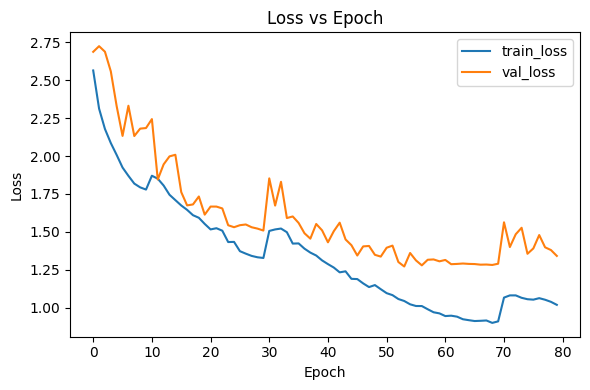

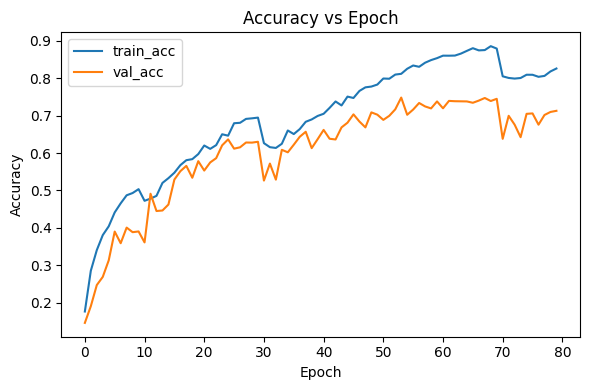

In [ ]:

# === LEARNING CURVES ===
with open(HIST_PATH, 'r') as f:
    h = json.load(f)

fig = plt.figure(figsize=(6,4))
plt.plot(h['train_loss'], label='train_loss')
plt.plot(h['val_loss'], label='val_loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(6,4))
plt.plot(h['train_acc'], label='train_acc')
plt.plot(h['val_acc'], label='val_acc')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Junior\AppData\Local\Temp\ipykernel_3884\1035377677.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_locat

Best checkpoint -> val_loss: 0.8829 | val_acc: 0.7484 (74.84%)

--- Test-Time Augmentation (TTA) ---
TTA -> val_loss: 0.8810 | val_acc: 0.7447 (74.47%)
Improvement: +-0.36%

Classification report:
              precision    recall  f1-score   support

           0     0.7885    0.7455    0.7664        55
           1     0.6316    0.8727    0.7328        55
           2     0.4921    0.5636    0.5254        55
           3     0.8148    0.8000    0.8073        55
           4     0.8723    0.7455    0.8039        55
           5     0.8409    0.6727    0.7475        55
           6     0.8364    0.8364    0.8364        55
           7     0.6667    0.5455    0.6000        55
           8     0.8621    0.9091    0.8850        55
           9     0.8421    0.5818    0.6882        55
          10     0.6727    0.6727    0.6727        55
          11     0.7600    0.6909    0.7238        55
          12     0.7778    0.7636    0.7706        55
          13     0.7541    0.8364    0.7931   

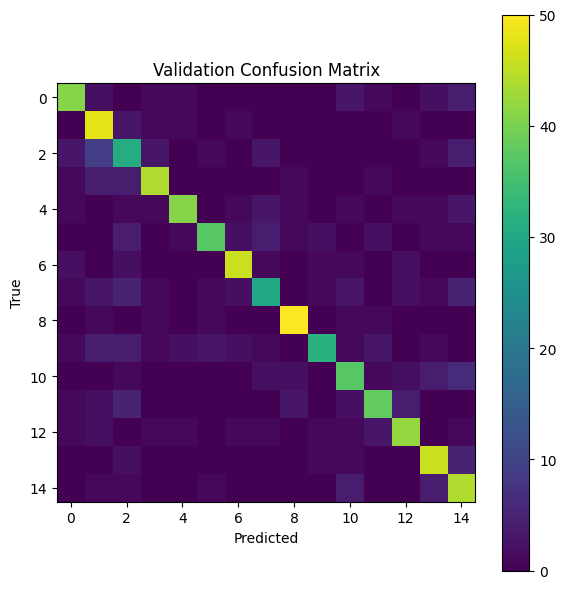

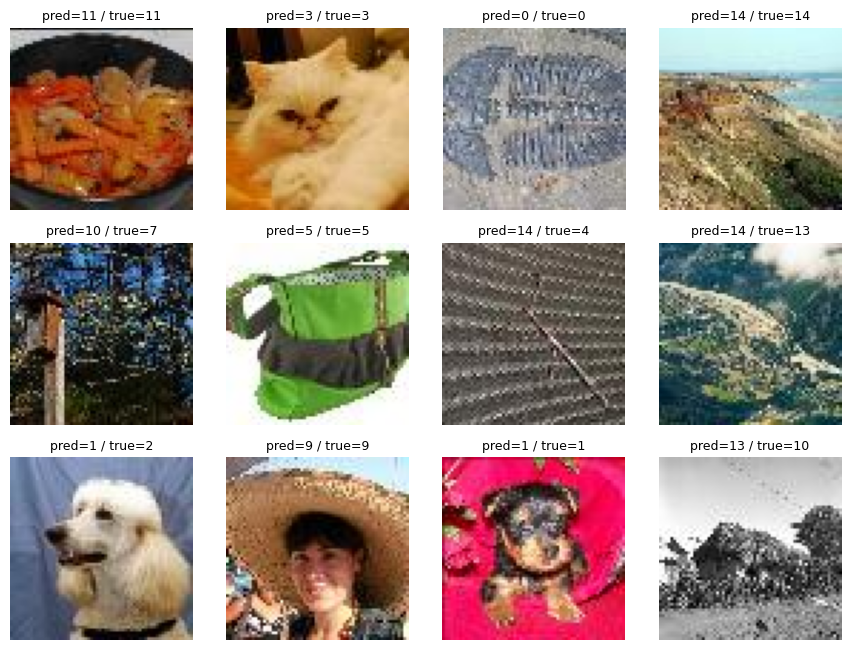

In [ ]:

# === EVALUATION ===
best = TinyCNN(num_classes=NUM_CLASSES).to(DEVICE)
best.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE))

# Standard evaluation
val_loss, val_acc = evaluate(best, val_loader, nn.CrossEntropyLoss())
print(f'Best checkpoint -> val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} ({val_acc*100:.2f}%)')

# ADVANCED: Test-Time Augmentation (TTA) - usually improves accuracy by 1-2%
print('\n--- Test-Time Augmentation (TTA) ---')
val_loss_tta, val_acc_tta = evaluate(best, val_loader, nn.CrossEntropyLoss(), use_tta=True)
print(f'TTA -> val_loss: {val_loss_tta:.4f} | val_acc: {val_acc_tta:.4f} ({val_acc_tta*100:.2f}%)')
print(f'Improvement: +{(val_acc_tta - val_acc)*100:.2f}%')

# Collect predictions
all_preds, all_labels = [], []
best.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = best(xb)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy().tolist())

print('\nClassification report:')
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds, labels=sorted(set(all_labels)))
fig = plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.show()

# Show a few validation images with predictions vs truth
def show_val_samples(ds: Dataset, preds: List[int], labels: List[int], n: int = 12):
    cols = 4
    rows = int(np.ceil(n/cols))
    fig = plt.figure(figsize=(cols*2.2, rows*2.2))
    step = max(1, len(ds)//n)
    idxs = list(range(0, len(ds), step))[:n]
    for i, idx in enumerate(idxs):
        x, y = ds[idx]
        mean = torch.tensor(NORM_MEAN).view(3,1,1)
        std  = torch.tensor(NORM_STD).view(3,1,1)
        x_disp = x*std + mean
        x_np = x_disp.numpy().transpose(1,2,0)
        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(np.clip(x_np, 0, 1))
        ax.set_title(f'pred={preds[idx]} / true={labels[idx]}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

preds_in_order = []
labels_in_order = []
best.eval()
with torch.no_grad():
    for i in range(len(val_ds)):
        x, y = val_ds[i]
        logits = best(x.unsqueeze(0).to(DEVICE))
        pred = int(logits.argmax(dim=1).item())
        preds_in_order.append(pred)
        labels_in_order.append(y)

show_val_samples(val_ds, preds_in_order, labels_in_order, n=12)


In [ ]:

# === SUBMISSION HELPERS ===
def load_model(weights_path: str, num_classes: Optional[int] = None) -> TinyCNN:
    if num_classes is None and os.path.exists(META_PATH):
        with open(META_PATH, 'r') as f:
            m = json.load(f)
        num_classes = int(m.get('num_classes', NUM_CLASSES if NUM_CLASSES else 15))
    elif num_classes is None:
        num_classes = NUM_CLASSES if NUM_CLASSES else 15

    model = TinyCNN(num_classes=num_classes)
    state = torch.load(weights_path, map_location='cpu')
    model.load_state_dict(state, strict=True)
    model.eval()
    return model

@torch.no_grad()
def predict(model_or_weights, data, use_tta=False):
    # Returns integer class predictions for numpy arrays or torch loaders/datasets
    # use_tta=True: Test-Time Augmentation (averages predictions from multiple augmented versions)
    if isinstance(model_or_weights, str):
        model = load_model(model_or_weights)
    else:
        model = model_or_weights
    model = model.to(DEVICE)
    model.eval()
    
    # TTA transforms for better accuracy
    if use_tta:
        tta_transforms = [
            lambda x: x,  # Original
            lambda x: torch.flip(x, [3]),  # Horizontal flip
            lambda x: torch.rot90(x, 1, [2, 3]),  # Rotate 90
            lambda x: torch.rot90(x, 2, [2, 3]),  # Rotate 180
            lambda x: torch.rot90(x, 3, [2, 3]),  # Rotate 270
        ]

    def _predict_from_array(arr: np.ndarray):
        if arr.ndim != 4:
            raise ValueError(f'Expected 4D array, got {arr.shape}')
        if arr.shape[-1] == 3:  # NHWC -> NCHW
            arr = np.transpose(arr, (0,3,1,2))
        x = arr.astype('float32')
        if x.max() > 1.5:
            x = x / 255.0
        x = torch.from_numpy(x).to(DEVICE)
        mean = torch.tensor(NORM_MEAN).view(1,3,1,1).to(DEVICE)
        std  = torch.tensor(NORM_STD).view(1,3,1,1).to(DEVICE)
        x = (x - mean) / std
        logits = model(x)
        return logits.argmax(dim=1).cpu().numpy().tolist()

    if isinstance(data, np.ndarray):
        return _predict_from_array(data)
    if isinstance(data, list):
        arr = np.stack([np.asarray(x) for x in data], axis=0)
        return _predict_from_array(arr)
    if isinstance(data, DataLoader):
        loader = data
    elif isinstance(data, Dataset):
        loader = DataLoader(data, batch_size=128, shuffle=False, num_workers=NUM_WORKERS)
    else:
        raise ValueError('Unsupported data type for predict(...)')

    preds_all = []
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy().tolist()
        preds_all.extend(preds)
    return preds_all


MODEL TESTING

1. Checking for trained model...
   Model path: c:\Users\Junior\Downloads\AI-Challenge\challenge\checkpoints\model.pth
   Model exists: True

   ✓ Model found! Loading...
   ✓ Model loaded successfully!

2. Testing forward pass...
   Input shape: torch.Size([4, 3, 64, 64])
   Output shape: torch.Size([4, 15])
   Predictions: [11, 11, 11, 11]
   True labels: [11, 11, 11, 11]
   ✓ Forward pass successful!

3. Evaluating on validation set...


C:\Users\Junior\AppData\Local\Temp\ipykernel_3884\3411140973.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, ma

   Validation Loss: 0.8829
   Validation Accuracy: 0.7484 (74.84%)
   ✓ Evaluation complete!

4. Computing detailed metrics...

   Classification Report:
              precision    recall  f1-score   support

           0     0.7885    0.7455    0.7664        55
           1     0.6316    0.8727    0.7328        55
           2     0.4921    0.5636    0.5254        55
           3     0.8148    0.8000    0.8073        55
           4     0.8723    0.7455    0.8039        55
           5     0.8409    0.6727    0.7475        55
           6     0.8364    0.8364    0.8364        55
           7     0.6667    0.5455    0.6000        55
           8     0.8621    0.9091    0.8850        55
           9     0.8421    0.5818    0.6882        55
          10     0.6727    0.6727    0.6727        55
          11     0.7600    0.6909    0.7238        55
          12     0.7778    0.7636    0.7706        55
          13     0.7541    0.8364    0.7931        55
          14     0.6027    0.8000  

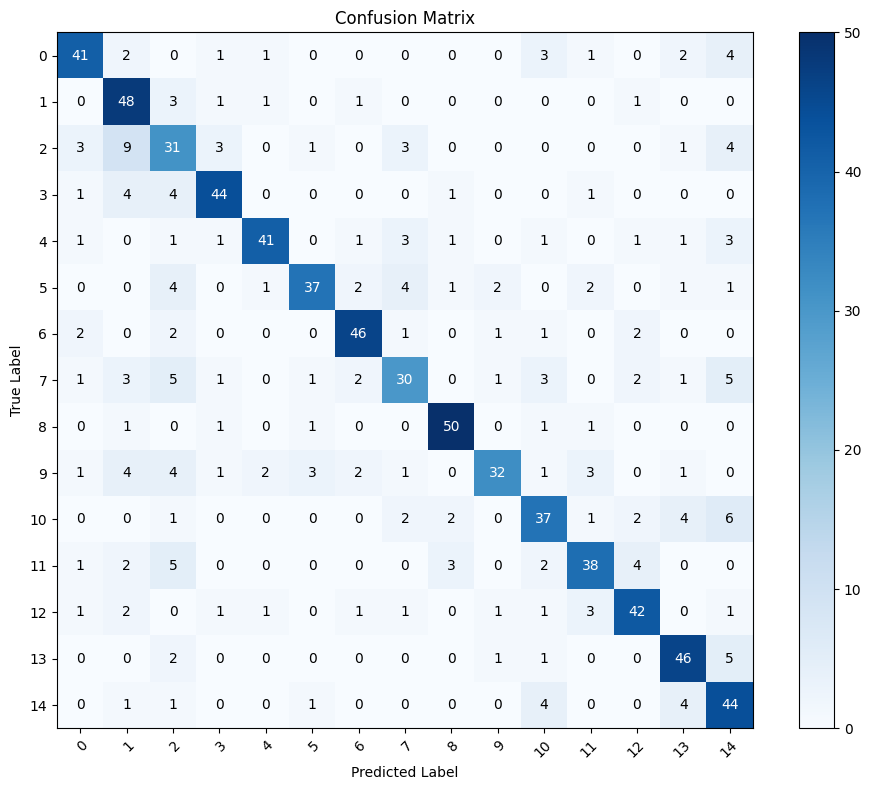

   ✓ Confusion matrix generated!

6. Visualizing sample predictions...


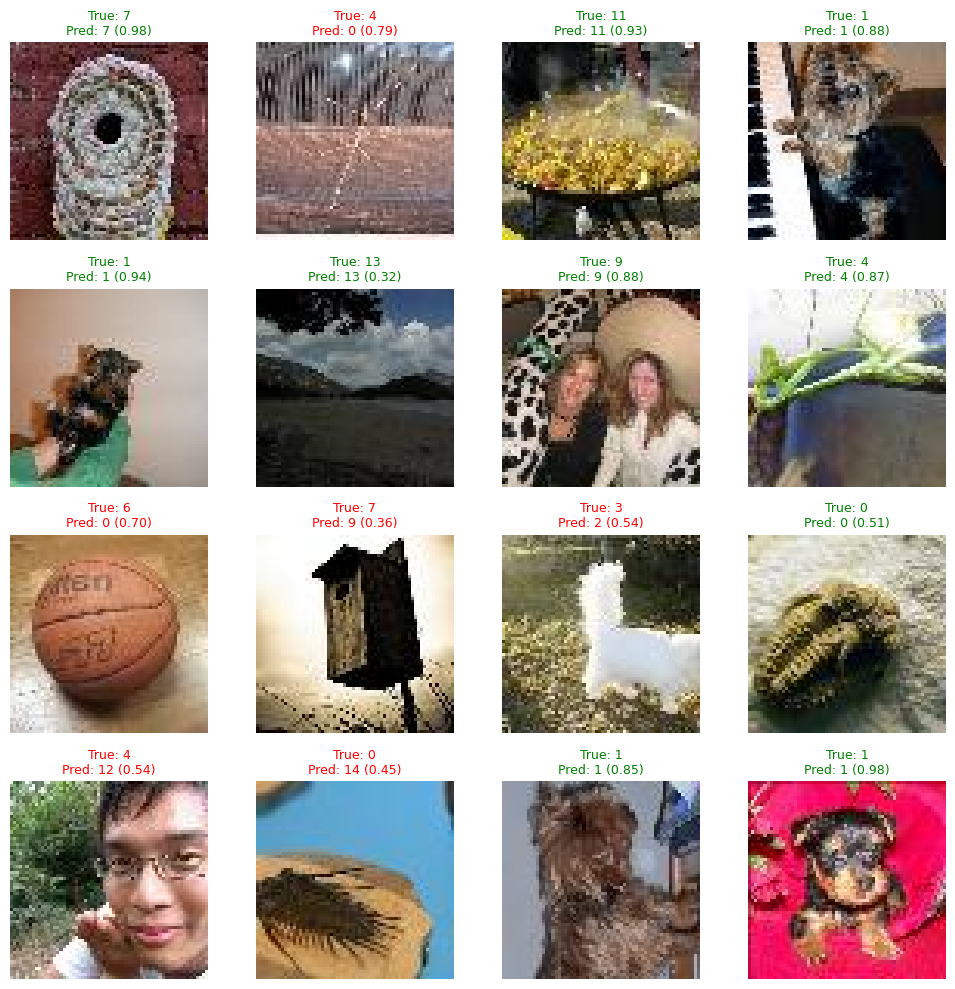

   ✓ Sample predictions visualized!

7. Model Summary:
   Total parameters: 5,773,999
   Trainable parameters: 5,773,999
   Model size: 22.03 MB (float32)

TESTING COMPLETE!


In [ ]:
# === COMPREHENSIVE MODEL TESTING ===
import os
from pathlib import Path

print("=" * 60)
print("MODEL TESTING")
print("=" * 60)

# Check if trained model exists
model_exists = Path(BEST_WEIGHTS_PATH).exists()
print(f"\n1. Checking for trained model...")
print(f"   Model path: {BEST_WEIGHTS_PATH}")
print(f"   Model exists: {model_exists}")

if not model_exists:
    print("\n   ⚠️  No trained model found!")
    print("   Please run the training cell (Cell 12) first, or test with untrained model.")
    print("   Testing with untrained model (will have poor performance)...")
    test_model = TinyCNN(num_classes=NUM_CLASSES).to(DEVICE)
else:
    print(f"\n   ✓ Model found! Loading...")
    test_model = TinyCNN(num_classes=NUM_CLASSES).to(DEVICE)
    test_model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location=DEVICE))
    print(f"   ✓ Model loaded successfully!")

# Test 1: Basic forward pass
print(f"\n2. Testing forward pass...")
test_model.eval()
sample_batch = next(iter(val_loader))
x_sample, y_sample = sample_batch
x_sample = x_sample[:4].to(DEVICE)  # Test with 4 samples
y_sample = y_sample[:4]

with torch.no_grad():
    logits = test_model(x_sample)
    preds = logits.argmax(dim=1).cpu()
    
print(f"   Input shape: {x_sample.shape}")
print(f"   Output shape: {logits.shape}")
print(f"   Predictions: {preds.tolist()}")
print(f"   True labels: {y_sample.tolist()}")
print(f"   ✓ Forward pass successful!")

# Test 2: Validation set evaluation
print(f"\n3. Evaluating on validation set...")
loss_fn = nn.CrossEntropyLoss()
val_loss, val_acc = evaluate(test_model, val_loader, loss_fn)
print(f"   Validation Loss: {val_loss:.4f}")
print(f"   Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   ✓ Evaluation complete!")

# Test 3: Detailed metrics
print(f"\n4. Computing detailed metrics...")
all_preds = []
all_labels = []
test_model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        logits = test_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(yb.numpy().tolist())

# Classification report
print("\n   Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Per-class accuracy
from collections import Counter
correct_by_class = Counter()
total_by_class = Counter()
for true_label, pred_label in zip(all_labels, all_preds):
    total_by_class[true_label] += 1
    if true_label == pred_label:
        correct_by_class[true_label] += 1

print("\n   Per-class Accuracy:")
for class_id in sorted(total_by_class.keys()):
    acc = correct_by_class[class_id] / total_by_class[class_id] if total_by_class[class_id] > 0 else 0
    print(f"   Class {class_id:2d}: {acc*100:6.2f}% ({correct_by_class[class_id]}/{total_by_class[class_id]})")

# Test 4: Confusion Matrix
print(f"\n5. Generating confusion matrix...")
cm = confusion_matrix(all_labels, all_preds, labels=sorted(set(all_labels)))
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xlabel='Predicted Label',
       ylabel='True Label',
       title='Confusion Matrix')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()
print(f"   ✓ Confusion matrix generated!")

# Test 5: Sample predictions visualization
print(f"\n6. Visualizing sample predictions...")
n_samples = 16
test_model.eval()
sample_indices = np.random.choice(len(val_ds), size=min(n_samples, len(val_ds)), replace=False)
cols = 4
rows = int(np.ceil(n_samples / cols))
fig = plt.figure(figsize=(cols*2.5, rows*2.5))

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        x, y_true = val_ds[idx]
        x_batch = x.unsqueeze(0).to(DEVICE)
        logits = test_model(x_batch)
        y_pred = int(logits.argmax(dim=1).item())
        prob = float(torch.softmax(logits, dim=1).max().item())
        
        # Denormalize for display
        mean = torch.tensor(NORM_MEAN).view(3,1,1)
        std = torch.tensor(NORM_STD).view(3,1,1)
        x_disp = x * std + mean
        x_np = np.clip(x_disp.numpy().transpose(1,2,0), 0, 1)
        
        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(x_np)
        color = 'green' if y_pred == y_true else 'red'
        ax.set_title(f'True: {y_true}\nPred: {y_pred} ({prob:.2f})', 
                    color=color, fontsize=9)
        ax.axis('off')
        
plt.tight_layout()
plt.show()
print(f"   ✓ Sample predictions visualized!")

# Test 6: Model summary
print(f"\n7. Model Summary:")
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")

print("\n" + "=" * 60)
print("TESTING COMPLETE!")
print("=" * 60)
